In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Dataset
transform = transforms.ToTensor()
train_data = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
test_data = datasets.MNIST(root='./data', train=False, transform=transform)
train_loader = DataLoader(train_data, batch_size=128, shuffle=True)
test_loader = DataLoader(test_data, batch_size=128)

# VAE definition
class VAE(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(784, 400)
        self.fc21 = nn.Linear(400, 20)
        self.fc22 = nn.Linear(400, 20)
        self.fc3 = nn.Linear(20, 400)
        self.fc4 = nn.Linear(400, 784)

    def encode(self, x):
        h1 = F.relu(self.fc1(x))
        return self.fc21(h1), self.fc22(h1)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h3 = F.relu(self.fc3(z))
        return torch.sigmoid(self.fc4(h3))

    def forward(self, x):
        x = x.view(-1, 784)
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar

# Loss Function
def loss_function(recon_x, x, mu, logvar, use_bce=True):
    x = x.view(-1, 784)
    if use_bce:
        recon_loss = F.binary_cross_entropy(recon_x, x, reduction='sum')
    else:
        recon_loss = F.mse_loss(recon_x, x, reduction='sum')
    kl_div = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + kl_div

# Train VAE
def train(model, use_bce=True, epochs=5):
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    model.train()
    for epoch in range(epochs):
        total_loss = 0
        for x, _ in train_loader:
            x = x.to(device)
            recon, mu, logvar = model(x)
            loss = loss_function(recon, x, mu, logvar, use_bce)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        print(f"{'BCE' if use_bce else 'MSE'} Epoch {epoch+1}, Loss: {total_loss / len(train_loader.dataset):.2f}")

# Pixel-wise Accuracy
def evaluate_accuracy(model):
    model.eval()
    total_acc = 0
    with torch.no_grad():
        for x, _ in test_loader:
            x = x.to(device)
            recon, _, _ = model(x)
            bin_recon = (recon > 0.5).float()
            bin_x = (x > 0.5).float()
            acc = (bin_recon == bin_x.view(-1, 784)).float().mean()
            total_acc += acc.item()
    return total_acc / len(test_loader)



# ---- RUN EVERYTHING ----
vae_bce = VAE().to(device)
vae_mse = VAE().to(device)

train(vae_bce, use_bce=True)
train(vae_mse, use_bce=False)

acc_bce = evaluate_accuracy(vae_bce)
acc_mse = evaluate_accuracy(vae_mse)

print(f"\nPixel-wise Accuracy (BCE): {acc_bce:.4f}")
print(f"Pixel-wise Accuracy (MSE): {acc_mse:.4f}")



BCE Epoch 1, Loss: 164.76
BCE Epoch 2, Loss: 121.71
BCE Epoch 3, Loss: 114.59
BCE Epoch 4, Loss: 111.54
BCE Epoch 5, Loss: 109.72
MSE Epoch 1, Loss: 45.39
MSE Epoch 2, Loss: 34.90
MSE Epoch 3, Loss: 33.13
MSE Epoch 4, Loss: 32.26
MSE Epoch 5, Loss: 31.73

Pixel-wise Accuracy (BCE): 0.9619
Pixel-wise Accuracy (MSE): 0.9440


In [15]:
def show_reconstruction_three_rows(model_bce, model_mse):
    model_bce.eval()
    model_mse.eval()
    with torch.no_grad():
        x, _ = next(iter(test_loader))
        x = x[:8].to(device)
        
        recon_bce, _, _ = model_bce(x)
        recon_mse, _, _ = model_mse(x)

        x = x.cpu()
        recon_bce = recon_bce.view(-1, 1, 28, 28).cpu()
        recon_mse = recon_mse.view(-1, 1, 28, 28).cpu()

        plt.figure(figsize=(16, 6))
        titles = ['Original', 'BCE', 'MSE']

        for row in range(3):
            for col in range(8):
                idx = row * 8 + col
                plt.subplot(3, 8, idx + 1)
                if row == 0:
                    plt.imshow(x[col][0], cmap='gray')
                    plt.title(f'{titles[0]}')
                elif row == 1:
                    plt.imshow(recon_bce[col][0], cmap='gray')
                    plt.title(f'{titles[1]}')
                    
                    
                else:
                    plt.imshow(recon_mse[col][0], cmap='gray')
                    plt.title(f'{titles[2]}')
                    
                    
                plt.axis('off')
                if col == 0:
                    plt.ylabel(titles[row], fontsize=12)

        plt.suptitle("Original and Reconstructed Images", fontsize=14)
        plt.tight_layout()
        plt.show()


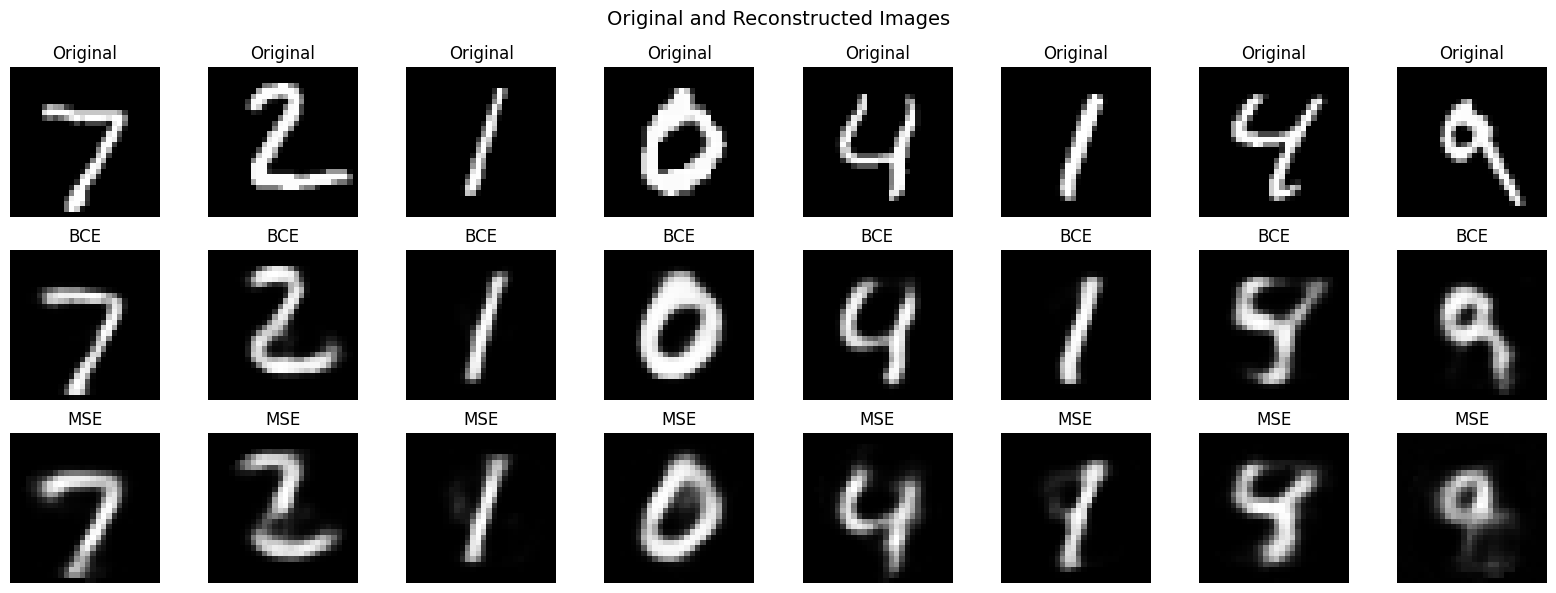

In [16]:
show_reconstruction_three_rows(vae_bce, vae_mse)